
# Seeing the FoV Flip Directly: Correlation Structure at Narrow vs. Wide FoV

**Purpose.** The earlier notebooks explained the FoV flip mathematically (via
$S_{\rm weak}$, eigenvalue counts, and the Johnson-scheme derivation). This notebook makes
the same point **visually** — showing the raw $\Gamma_{ab}$ correlation values themselves,
not statistics derived from them. The claim to check by eye: at narrow FoV, every pair of
stars has almost the *same* coupling (redundant information); at wide FoV, pairs have
genuinely *different* couplings (diverse information) — and that redundancy vs. diversity
is the entire mechanism behind the flip.

This only reads pre-computed data (`notebook2_gamma_matrices.npz`, produced by
`generate_notebook2_data.py`) — no slow solves in this notebook.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

d = dict(np.load("notebook2_gamma_matrices.npz"))
FoV_values = sorted(d["fov_done"].tolist())
N_fixed = int(d["N_fixed"])
print(f"N={N_fixed} fixed. FoV values available: {FoV_values}")


N=100 fixed. FoV values available: [10, 40, 100, 160]



## Histograms: the distribution of $\Gamma_{ab}$ across all pairs

If narrow FoV means "everyone agrees" and wide FoV means "everyone's saying something
different," that should show up directly as a narrow, tall spike vs. a wide, spread-out
distribution — including going negative (the HD kernel's anti-correlated lobe).


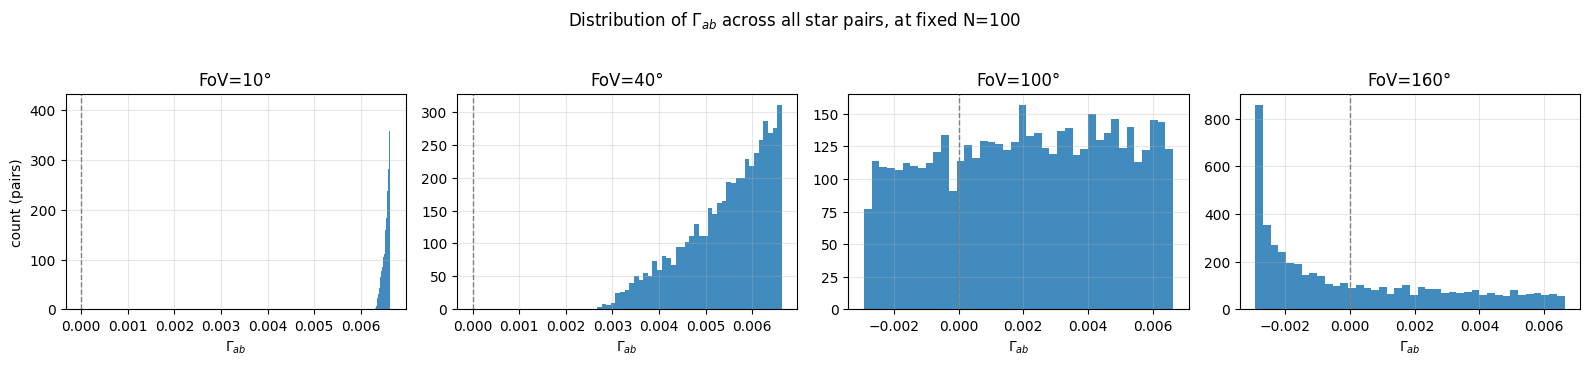

Spread (std) of Gamma_ab at each FoV -- a direct, model-free diversity measure:
  FoV= 10   mean=0.00655   std=0.00007   min=0.00631   max=0.00663
  FoV= 40   mean=0.00545   std=0.00090   min=0.00267   max=0.00663
  FoV=100   mean=0.00207   std=0.00270   min=-0.00292   max=0.00663
  FoV=160   mean=0.00010   std=0.00286   min=-0.00293   max=0.00663


In [2]:

fig, axes = plt.subplots(1, len(FoV_values), figsize=(4*len(FoV_values), 3.5), sharey=False)
for ax, fov in zip(axes, FoV_values):
    gamma = d[f"gamma_{fov}"]
    vals = gamma[np.triu_indices_from(gamma, k=1)]
    vals = vals[np.isfinite(vals)]
    ax.hist(vals, bins=40, color="C0", alpha=0.85)
    ax.set_title(f"FoV={fov}\u00b0")
    ax.set_xlabel(r"$\Gamma_{ab}$")
    ax.axvline(0, color="gray", ls="--", lw=1)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("count (pairs)")
plt.suptitle(r"Distribution of $\Gamma_{ab}$ across all star pairs, at fixed N=100", y=1.03)
plt.tight_layout()
plt.show()

print("Spread (std) of Gamma_ab at each FoV -- a direct, model-free diversity measure:")
for fov in FoV_values:
    gamma = d[f"gamma_{fov}"]
    vals = gamma[np.triu_indices_from(gamma, k=1)]
    vals = vals[np.isfinite(vals)]
    print(f"  FoV={fov:3d}   mean={vals.mean():.5f}   std={vals.std():.5f}   "
          f"min={vals.min():.5f}   max={vals.max():.5f}")



## Heatmaps: the actual pair-correlation matrix

Same data, shown as a matrix rather than a histogram. Stars are sorted by angle from the
field center, so nearby rows/columns correspond to nearby stars — this makes any structure
(or lack of it) visible directly, not just its aggregate statistics.


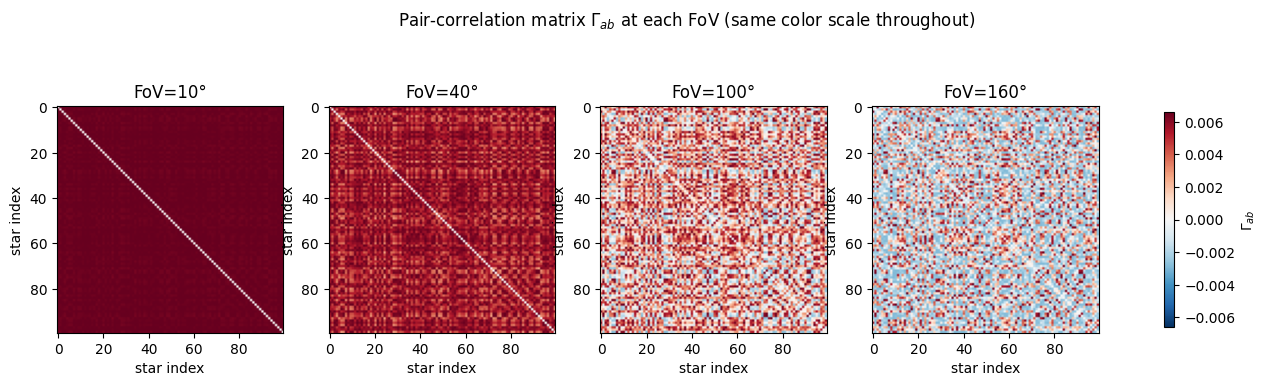

In [3]:

fig, axes = plt.subplots(1, len(FoV_values), figsize=(4.2*len(FoV_values), 4))
vmax = max(np.nanmax(np.abs(d[f"gamma_{fov}"])) for fov in FoV_values)
for ax, fov in zip(axes, FoV_values):
    gamma = d[f"gamma_{fov}"].copy()
    np.fill_diagonal(gamma, 0.0)
    im = ax.imshow(gamma, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"FoV={fov}\u00b0")
    ax.set_xlabel("star index"); ax.set_ylabel("star index")
fig.colorbar(im, ax=axes, shrink=0.7, label=r"$\Gamma_{ab}$")
plt.suptitle(r"Pair-correlation matrix $\Gamma_{ab}$ at each FoV (same color scale throughout)", y=1.02)
plt.show()



### Reading the heatmaps

- **FoV=10°**: the matrix is almost a single flat color — every pair has nearly the same
  (large, positive) correlation. This is the visual signature of the near-degenerate
  "star eigenspace" from the Johnson-scheme derivation: rows are nearly identical, so the
  covariance is close to singular in that direction, and inversion can't extract much
  independent information.
- **FoV=160°**: real texture and structure appear — patches of strong positive correlation,
  patches of negative correlation, genuine pair-to-pair variation. This is the direct,
  visual counterpart of "pairs are no longer redundant."

Nothing here is new information beyond the earlier $S_{\rm weak}$/eigenvalue analysis — but
seeing the actual matrix go from "flat" to "textured" as FoV widens is a much more
immediate way to communicate why inversion suddenly has more to work with.



## A single side-by-side comparison figure for a slide/talk

Same information, laid out as one publication/talk-ready figure: histogram and heatmap for
just the two extremes (narrowest vs. widest FoV), side by side.


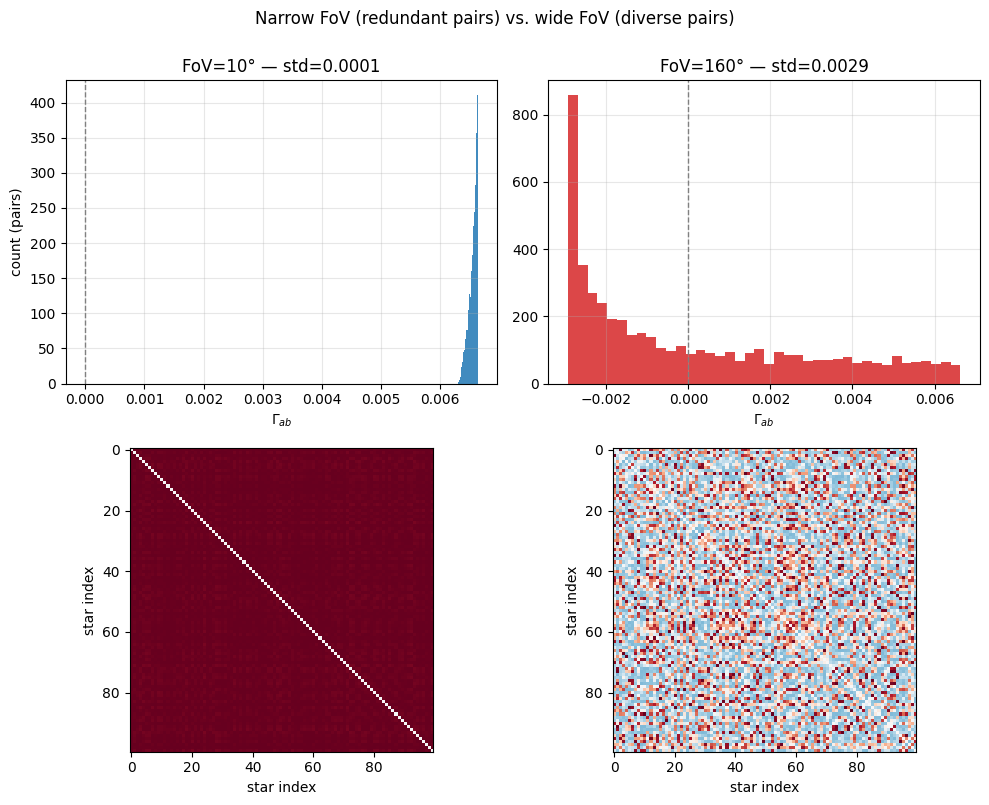

Saved: fov_flip_visual_summary.png


In [4]:

fov_lo, fov_hi = FoV_values[0], FoV_values[-1]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for col, fov in enumerate([fov_lo, fov_hi]):
    gamma = d[f"gamma_{fov}"]
    vals = gamma[np.triu_indices_from(gamma, k=1)]
    vals = vals[np.isfinite(vals)]
    axes[0, col].hist(vals, bins=40, color="C0" if col == 0 else "C3", alpha=0.85)
    axes[0, col].axvline(0, color="gray", ls="--", lw=1)
    axes[0, col].set_title(f"FoV={fov}\u00b0 \u2014 std={vals.std():.4f}")
    axes[0, col].set_xlabel(r"$\Gamma_{ab}$")
    axes[0, col].grid(alpha=0.3)

    gamma_plot = gamma.copy(); np.fill_diagonal(gamma_plot, 0.0)
    im = axes[1, col].imshow(gamma_plot, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    axes[1, col].set_xlabel("star index"); axes[1, col].set_ylabel("star index")

axes[0, 0].set_ylabel("count (pairs)")
plt.suptitle("Narrow FoV (redundant pairs) vs. wide FoV (diverse pairs)", y=1.0)
plt.tight_layout()
plt.savefig("fov_flip_visual_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fov_flip_visual_summary.png")
